# Load libraries

In [7]:
%reload_ext autoreload
%autoreload 2

import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import pickle
import os
import h5py
from py4DSTEM import show
import time
from sklearn import cluster
from scipy.signal import fftconvolve
from scipy.spatial import distance
from scipy.ndimage import binary_dilation
from microstructure_inference.dataModules import cubic_proper_point_group_operations
from microstructure_inference.dataProcessing import point_in_spherical_triangle_oriented, assignment_cost_pairwise_distance,  sample_rotation_at_rand_geodesic_distance, _subtract_dog, generate_random_colormap
from skimage.transform import AffineTransform, warp
from matplotlib.colors import ListedColormap, BoundaryNorm
import random
import colorsys

print(py4DSTEM.__version__)
%autoreload 2

pixel_size_inv_Ang_guess = 0.0328
k_max = pixel_size_inv_Ang_guess * 60


0.14.8


In [46]:
def generate_colormap(class_label, syn_2D_scanSpace_map, class_0_colors, class_1_colors, num_colors=60, background_color="#ffffff"):
    """
    Generate a matplotlib ListedColormap with `num_colors` random colors,
    and optionally add a background color at index 0.
    
    Parameters:
        num_colors (int): Number of random colors (for grains).
        background_color (tuple): RGB tuple for background (index 0).
    
    Returns:
        ListedColormap: Colormap object for use in matplotlib.
    """
    # rng = np.random.default_rng(seed=12)  # For reproducibility
    # random_colors = rng.uniform(0.1, 0.9, size=(num_colors, 3))  # Avoid too dark/light

    # Prepend background color at index 0
    custom_colors = []
    custom_colors.append(background_color)
    class_0_color_grain_count = 0
    class_1_color_grain_count = 0
    
    for grain_index in range(1, int(np.max(syn_2D_scanSpace_map) + 1)):

        x_grain_idx, y_grain_idx = np.where(syn_2D_scanSpace_map==grain_index)


        # class 0 - Cu_fcc
        if np.average(class_label[x_grain_idx, y_grain_idx]) < 0.5:
            custom_colors.append(class_0_colors[class_0_color_grain_count])
            class_0_color_grain_count += 1
        else:

            custom_colors.append(class_1_colors[class_1_color_grain_count])
            class_1_color_grain_count += 1
        
    custom_colors_stacked = np.vstack([custom_colors])
    
    return ListedColormap(custom_colors)

def sample_colors(base_hex, n, hue_variation=0.04, light_variation=0.07, sat_variation=0.07):
    # Convert HEX to RGB
    base_rgb = tuple(int(base_hex[i:i+2], 16)/255 for i in (1,3,5))
    base_hls = colorsys.rgb_to_hls(*base_rgb)
    
    colors = []
    for _ in range(n):
        h = (base_hls[0] + random.uniform(-hue_variation, hue_variation)) % 1
        l = min(max(base_hls[1] + random.uniform(-light_variation, light_variation), 0), 1)
        s = min(max(base_hls[2] + random.uniform(-sat_variation, sat_variation), 0), 1)
        rgb = colorsys.hls_to_rgb(h, l, s)
        colors.append('#{:02X}{:02X}{:02X}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)))
    return colors

def return_angle_between_two_vectors_in_radian(vec_a, vec_b):

    normalized_vec_a = vec_a / np.linalg.norm(vec_a)
    normalized_vec_b = vec_b / np.linalg.norm(vec_b)
    
    # Calculate the dot product
    dot_product = np.dot(normalized_vec_a, normalized_vec_b)

    dot_product = np.clip(dot_product, -1.0, 1.0)
    
    # Calculate the angle in radians
    theta = np.arccos(dot_product)

    return theta


# Load data

In [47]:
file_path = os.getcwd() + "/"
data_path = "/home/kwang/Desktop/Storage/project/p03_orientation_mapping/figure/figure_06/"

# customPROBE.shape
# datacube_aligned_data = py4DSTEM.DataCube(new_4d_tot)

In [48]:
filepath_braggdisks_cal = data_path + 'synthetic_4DSTEM_braggdisks.h5'
# py4DSTEM.save(
#     filepath_braggdisks_cal,
#     bragg_peaks,
#     mode='o',
# )

bragg_peaks = py4DSTEM.read(
    filepath_braggdisks_cal, 
)

Reading PointListArray: 100%|███| 16384/16384 [00:00<00:00, 17549.97PointList/s]


In [49]:
class_label = np.load(data_path + "multi_crystal_synthetic_4DSTEM_data_crystalClass_labels.npy")

In [39]:
type(class_label[0][0])

numpy.int64

In [40]:
class_label

array([[2, 2, 2, ..., 2, 2, 2],
       [2, 0, 0, ..., 0, 0, 2],
       [2, 0, 0, ..., 0, 0, 2],
       ...,
       [2, 0, 0, ..., 0, 0, 2],
       [2, 0, 0, ..., 0, 0, 2],
       [2, 2, 2, ..., 2, 2, 2]], shape=(128, 128))

## Perform py4DSTEM ACOM template matching for Cu fcc

In [50]:
k_max = 0.0328 * 60
accelerating_voltage = int(300e3)
crystal_Cu = py4DSTEM.process.diffraction.Crystal.from_CIF(file_path + "Cu_fcc.cif")
crystal_Cu.setup_diffraction(accelerating_voltage)
crystal_Cu.calculate_structure_factors(
    k_max,
)

# Create an orientation plan for [0001] WS2
crystal_Cu.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = accelerating_voltage,
    corr_kernel_size=0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 6139.23 zone axes/s]


In [8]:
start_perf = time.perf_counter()

orientation_map_Cu = crystal_Cu.match_orientations(
                                            bragg_peaks,
                                            )
end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf

print(f"High-resolution execution time: {elapsed_perf:.6f} seconds")


/home/kwang/anaconda3/envs/oriMap-env/lib/python3.11/site-packages/py4DSTEM/process/diffraction/crystal_ACOM.py:814: UserWarning: bragg peaks not rotationally calibrated
  warn("bragg peaks not rotationally calibrated")
Matching Orientations: 100%|██████| 16384/16384 [03:45<00:00, 72.59 PointList/s]

High-resolution execution time: 225.714594 seconds


In [9]:
with open("orientation_map_Cu_fcc.pkl", "wb") as f:
    pickle.dump(orientation_map_Cu, f)

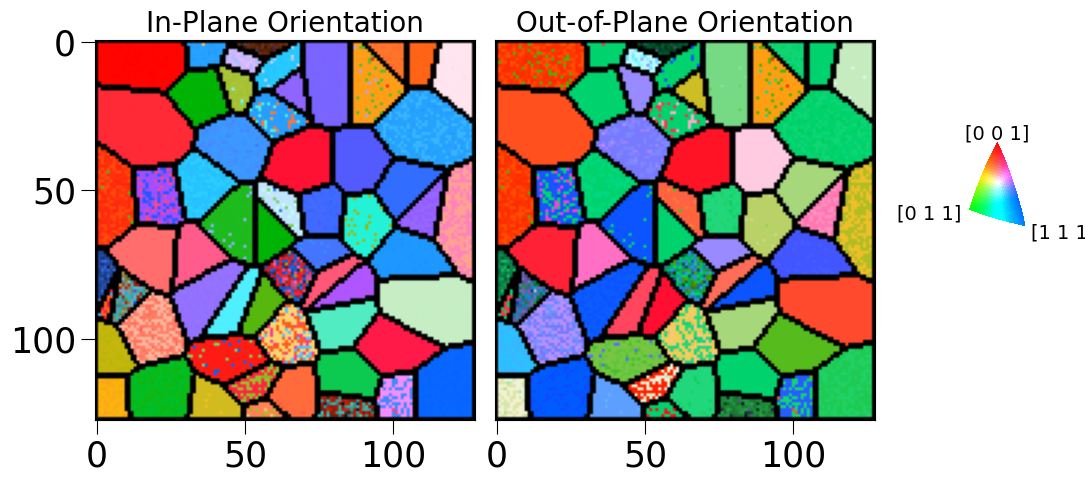

In [12]:
images_orientation, fig_temp, ax_temp = crystal_Cu.plot_orientation_maps(
    orientation_map_Cu,
    # symmetry_order = 6,
    corr_range = [0.1, 0.5],
    figsize = (10,10),
    returnfig = True,
)
# fig_temp.savefig(file_path + "orientation_color_map_temp_matching_Cu_fcc.pdf", bbox_inches='tight', dpi = 300)
# fig_temp.savefig(file_path + "orientation_color_map_temp_matching_Cu_fcc.png", bbox_inches='tight', dpi = 300)
plt.show()

## Perform py4DSTEM ACOM template matching for Cu2O cubic

In [51]:
k_max = 0.0328 * 60
accelerating_voltage = int(300e3)
crystal_Cu2O = py4DSTEM.process.diffraction.Crystal.from_CIF(file_path + "Cu2O_cubic.cif")
crystal_Cu2O.setup_diffraction(accelerating_voltage)
crystal_Cu2O.calculate_structure_factors(
    k_max,
)

# Create an orientation plan for [0001] WS2
crystal_Cu2O.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = accelerating_voltage,
    corr_kernel_size=0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 1451.67 zone axes/s]


In [14]:
start_perf = time.perf_counter()

orientation_map_Cu2O = crystal_Cu2O.match_orientations(
                                            bragg_peaks,
                                            )
end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf

print(f"High-resolution execution time: {elapsed_perf:.6f} seconds")


/home/kwang/anaconda3/envs/oriMap-env/lib/python3.11/site-packages/py4DSTEM/process/diffraction/crystal_ACOM.py:814: UserWarning: bragg peaks not rotationally calibrated
  warn("bragg peaks not rotationally calibrated")
Matching Orientations: 100%|██████| 16384/16384 [09:58<00:00, 27.38 PointList/s]

High-resolution execution time: 598.389844 seconds


In [15]:
with open("orientation_map_Cu2O_cubic.pkl", "wb") as f:
    pickle.dump(orientation_map_Cu2O, f)

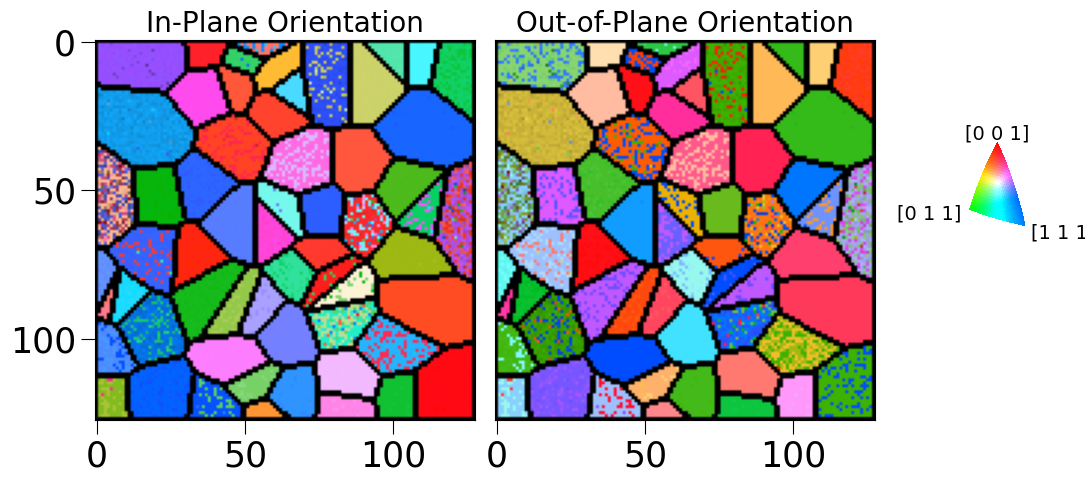

In [17]:
images_orientation, fig_temp, ax_temp = crystal_Cu2O.plot_orientation_maps(
    orientation_map_Cu2O,
    # symmetry_order = 6,
    corr_range = [0.1, 0.5],
    figsize = (10,10),
    returnfig = True,
)
# fig_temp.savefig(file_path + "orientation_color_map_temp_matching_Cu2O_cubic.pdf", bbox_inches='tight', dpi = 300)
# fig_temp.savefig(file_path + "orientation_color_map_temp_matching_Cu2O_cubic.png", bbox_inches='tight', dpi = 300)
plt.show()

## phase identification using correlation score

Note that this phase identification is not rigorous because we use corrleation scores from Cu_fcc and Cu2O_cubic crystal librarires respectively, and the scores are prepared with different normalization scheme.

In [52]:
start_perf = time.perf_counter()


scan_x_dimension = int(bragg_peaks.shape[0])
scan_y_dimension = int(bragg_peaks.shape[1])

phase_identity_fromCorrScore = np.zeros((scan_x_dimension, scan_y_dimension), dtype = np.int64)

threshold = 1e-6
min_number_peaks = 3
for xind in range(scan_x_dimension):
    for yind in range(scan_y_dimension):
        bragg_peak = bragg_peaks.cal[xind,yind]
        if bragg_peak.data.shape[0] < min_number_peaks:
            phase_identity_fromCorrScore[xind,yind] = 2
        else:
        
            Cu_fcc_orientation = crystal_Cu.match_single_pattern(
                bragg_peak,
                verbose = False,
            )
    
            Cu_fcc_correlation_score = Cu_fcc_orientation.corr[0]
        
            Cu2O_cubic_orientation = crystal_Cu2O.match_single_pattern(
                bragg_peak,
                verbose = False,
            )
    
            Cu2O_cubic_correlation_score = Cu2O_cubic_orientation.corr[0]

            if Cu_fcc_correlation_score > Cu2O_cubic_correlation_score:
                phase_identity_fromCorrScore[xind,yind] = 0
            else:
                phase_identity_fromCorrScore[xind,yind] = 1



            del Cu_fcc_correlation_score, Cu2O_cubic_correlation_score
    
        
end_perf = time.perf_counter()
elapsed_perf = end_perf - start_perf

print(f"High-resolution execution time: {elapsed_perf:.6f} seconds")

        
        

High-resolution execution time: 740.570455 seconds


In [53]:
phase_identity_fromCorrScore

array([[2, 2, 2, ..., 2, 2, 2],
       [2, 0, 0, ..., 0, 0, 2],
       [2, 0, 0, ..., 0, 0, 2],
       ...,
       [2, 0, 0, ..., 0, 0, 2],
       [2, 0, 0, ..., 0, 0, 2],
       [2, 2, 2, ..., 2, 2, 2]], shape=(128, 128))

In [54]:
np.save("phase_identity_assigned_by_correlationScore_from_Cu_and_Cu2O.npy", phase_identity_fromCorrScore)

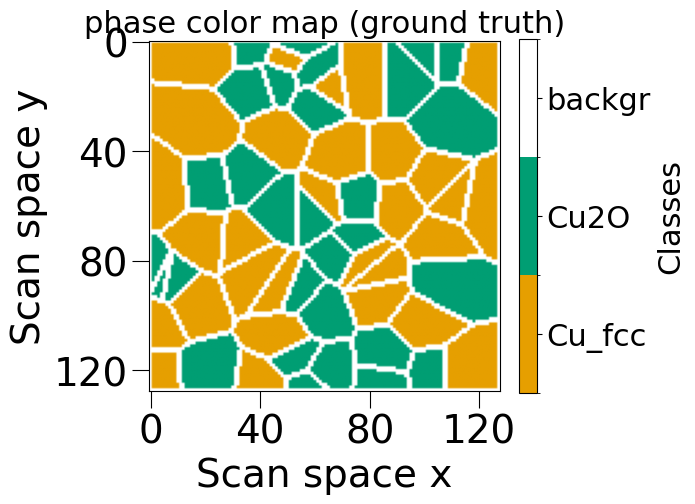

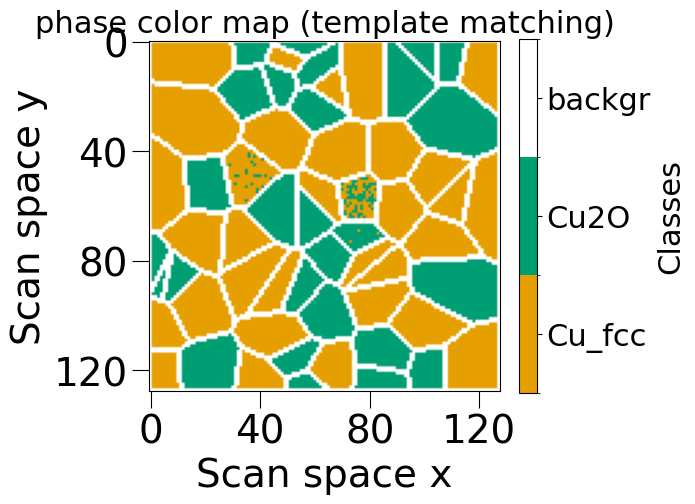

In [80]:



class_labels = ['Cu_fcc', 'Cu2O','backgr']
tick_positions = [0.5, 1.5, 2.5]

phase_class_color_map = ListedColormap(["#E69F00", "#009E73", "#ffffff"])
phase_class_color_bounds = np.array([0, 1, 2, 3])
phase_class_color_norm = BoundaryNorm(phase_class_color_bounds, 3)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title("phase color map (ground truth)", fontsize=22)
im = ax.imshow(class_label, cmap=phase_class_color_map, norm=phase_class_color_norm, rasterized=True)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax.set_xticks([0, 40, 80, 120])
ax.set_yticks([0, 40, 80, 120])
ax.set_xlabel(r"Scan space x", fontsize = 28)
ax.set_ylabel(r"Scan space y", fontsize = 28)

# Add the colorbar with custom ticks and labels
cbar = fig.colorbar(im, ax=ax, fraction=0.0457, ticks=phase_class_color_bounds)
# Set custom ticks and labels on the colorbar
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(class_labels, fontsize=22)
cbar.set_label("Classes", fontsize=22)
plt.savefig("revision_phase_color_map_ground_truth.pdf", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig("revision_phase_color_map_ground_truth.png", bbox_inches='tight', facecolor='white', edgecolor='none', dpi = 300,transparent=False)
plt.savefig("revision_phase_color_map_ground_truth.svg", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.show()

class_labels = ['Cu_fcc', 'Cu2O','backgr']
tick_positions = [0.5, 1.5, 2.5]

phase_class_color_map = ListedColormap(["#E69F00", "#009E73", "#ffffff"])
phase_class_color_bounds = np.array([0, 1, 2, 3])
phase_class_color_norm = BoundaryNorm(phase_class_color_bounds, 3)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title("phase color map (template matching)", fontsize=22)
im = ax.imshow(phase_identity_fromCorrScore, cmap=phase_class_color_map, norm=phase_class_color_norm, rasterized=True)
# Set axis labels
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax.set_xticks([0, 40, 80, 120])
ax.set_yticks([0, 40, 80, 120])
ax.set_xlabel(r"Scan space x", fontsize = 28)
ax.set_ylabel(r"Scan space y", fontsize = 28)

# Add the colorbar with custom ticks and labels
cbar = fig.colorbar(im, ax=ax, fraction=0.0457, ticks=phase_class_color_bounds)
# Set custom ticks and labels on the colorbar
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(class_labels, fontsize=22)
cbar.set_label("Classes", fontsize=22)
plt.savefig("revision_templateMatching_from_corrScoreComparison_phase_color_map_prediction.pdf", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig("revision_templateMatching_from_corrScoreComparison_phase_color_map_prediction.png", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.savefig("revision_templateMatching_from_corrScoreComparison_phase_color_map_prediction.svg", bbox_inches='tight', facecolor='white', edgecolor='none',dpi = 300,transparent=False)
plt.show()

## assigned orientation based on phase identity from correlation score comparison

In [74]:
from microstructure_inference.dataProcessing import pre_process_experimental_BraggDisk, pre_process_synthetic_4DSTEM, process_pandas_tabular_data, predict_rotation_and_phase_experimental_data, make_orientation_map_based_on_4D_rotation_matrices

In [75]:
with open("orientation_map_Cu2O_cubic.pkl", "rb") as f:
    orientation_map_Cu2O = pickle.load(f)

with open("orientation_map_Cu_fcc.pkl", "rb") as f:
    orientation_map_Cu = pickle.load(f)
    

In [76]:
orient_tot = np.load(data_path + "multi_crystal_synthetic_4DSTEM_data_rotationMat_labels.npy")
orientation_Map_ground_truth = make_orientation_map_based_on_4D_rotation_matrices(orient_tot, crystal_Cu)

In [77]:
rotation_matrices_predicted_np_4D = np.zeros((scan_x_dimension, scan_y_dimension, 3, 3))

for xind in range(scan_x_dimension):
    for yind in range(scan_y_dimension):

        phase_identity = phase_identity_fromCorrScore[xind,yind]

        # Cu_fcc (identity index 0)
        if phase_identity == 0:
            rotation_matrices_predicted_np_4D[xind,yind] = orientation_map_Cu.matrix[xind,yind,0]

        # Cu2O_cubic (identity index 1)
        elif phase_identity == 1:
            rotation_matrices_predicted_np_4D[xind,yind] = orientation_map_Cu2O.matrix[xind,yind,0]



In [78]:
orientation_Map_template_matching = make_orientation_map_based_on_4D_rotation_matrices(rotation_matrices_predicted_np_4D, crystal_Cu)



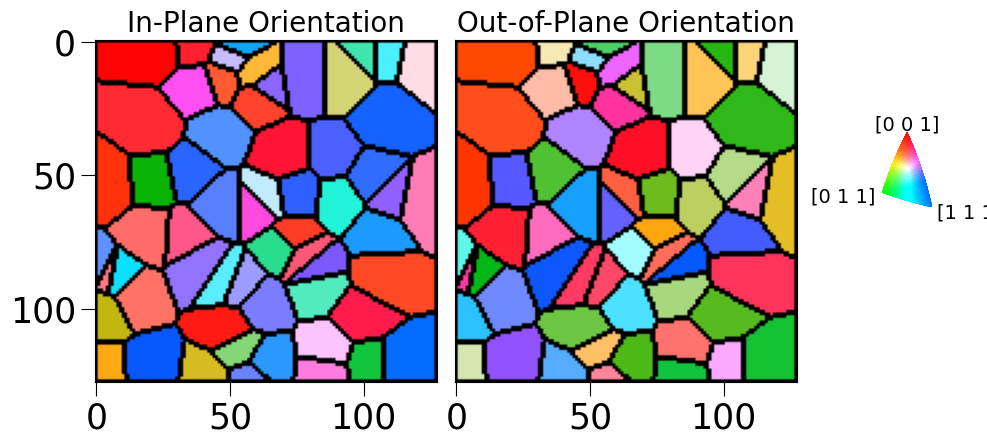

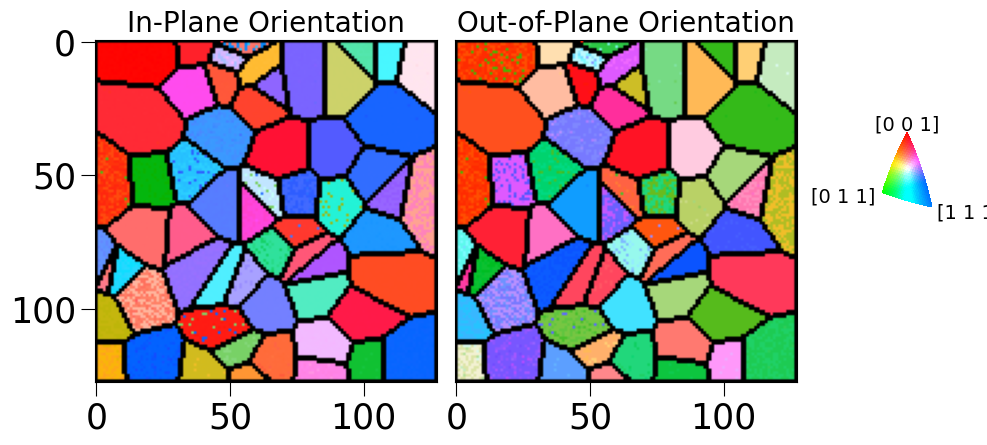

In [81]:

images_orientation_ground_truth, fig_ground_truth, ax_ground_truth = crystal_Cu.plot_orientation_maps(
    orientation_Map_ground_truth,
    # orientation_ind=0,
    # symmetry_order = 6,
    corr_range = [0.9, 1.0],
    figsize = (9,9),
    returnfig = True,
)


ax_ground_truth[0].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_ground_truth[0].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_ground_truth[0].set_xticks([0, 40, 80, 120])
ax_ground_truth[0].set_yticks([0, 40, 80, 120])
ax_ground_truth[0].set_xlabel(r"Scan space x", fontsize = 28)
ax_ground_truth[0].set_ylabel(r"Scan space y", fontsize = 28)

ax_ground_truth[1].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_ground_truth[1].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_ground_truth[1].set_xticks([0, 40, 80, 120])
ax_ground_truth[1].set_yticks([0, 40, 80, 120])
ax_ground_truth[1].set_xlabel(r"Scan space x", fontsize = 28)
ax_ground_truth[1].set_ylabel(r"Scan space y", fontsize = 28)


ax_ground_truth[1].set_yticks([])
ax_ground_truth[1].set_ylabel("")

fig_ground_truth.savefig("revision_orientation_color_map_ground_truth.pdf", bbox_inches='tight', dpi = 300)
fig_ground_truth.savefig("revision_orientation_color_map_ground_truth.png", bbox_inches='tight', dpi = 300)
plt.show()


images_orientation_pred, fig_pred, ax_pred = crystal_Cu.plot_orientation_maps(
    orientation_Map_template_matching,
    # orientation_ind=0,
    # symmetry_order = 6,
    corr_range = [0.9, 1.0],
    figsize = (9,9),
    returnfig = True,
)

ax_pred[0].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[0].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[0].set_xticks([0, 40, 80, 120])
ax_pred[0].set_yticks([0, 40, 80, 120])
ax_pred[0].set_xlabel(r"Scan space x", fontsize = 28)
ax_pred[0].set_ylabel(r"Scan space y", fontsize = 28)

ax_pred[1].tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[1].tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax_pred[1].set_xticks([0, 40, 80, 120])
ax_pred[1].set_yticks([0, 40, 80, 120])
ax_pred[1].set_xlabel(r"Scan space x", fontsize = 28)
ax_pred[1].set_ylabel(r"Scan space y", fontsize = 28)


ax_pred[1].set_yticks([])
ax_pred[1].set_ylabel("")

fig_pred.savefig("revision_templateMatching_from_corrScoreComparison_orientation_color_map_pred.pdf", bbox_inches='tight', dpi = 300)
fig_pred.savefig("revision_templateMatching_from_corrScoreComparison_orientation_color_map_pred.png", bbox_inches='tight', dpi = 300)
plt.show()
